# TP : Filtrage Convolutionnel d'une Image

Le but de ce TP est de comprendre et d'expérimenter l'effet des filtres de convolution sur une image. 

À travers différentes étapes, vous apprendrez à manipuler des images, appliquer des filtres pour extraire des caractéristiques telles que les contours, et observer l'impact de fonctions non linéaires sur les résultats. 

Ce travail pratique vous permettra d'acquérir une intuition sur le rôle fondamental de la convolution dans le traitement d'image et la vision par ordinateur.


### Préparer l'environnement de traitement d'image
Importez l'ensemble des bibliothèques utiles :
- `os` pour gérer les chemins
- `cv2` d'OpenCV pour la lecture et la manipulation d'images
- `matplotlib.pyplot` pour l'affichage
- `numpy` pour les opérations matricielles
- `torch` et `torch.nn.functional` afin d'appliquer des convolutions différentiables


In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

### Charger l'image source

Effectuez les étapes suivantes pour charger et préparer l'image :

- Définissez le chemin du dossier contenant les images (`img_dir`)
- Spécifiez le nom du fichier image à analyser (`img_name`)
- Utilisez `cv2.imread` pour charger l'image en mémoire (`image`)
- Vérifiez la forme de l'image avec `.shape` pour contrôler les dimensions (hauteur, largeur, canaux) avant les traitements ultérieurs


In [2]:
img_dir = '../data/images_convolutions/'
img_name = 'Lenna.png'
image = cv2.imread(os.path.join(img_dir, img_name))
print(image.shape)


(512, 512, 3)


### Préparer l'affichage RGB

Convertissez l'image chargée de BGR vers RGB et affichez-la

- Utilisez `cv2.cvtColor` pour convertir `image` de BGR vers RGB et stocker le résultat dans `image_rgb`
- Utilisez `plt.imshow` pour afficher `image_rgb`
- Utilisez `plt.show()` pour afficher le résultat final


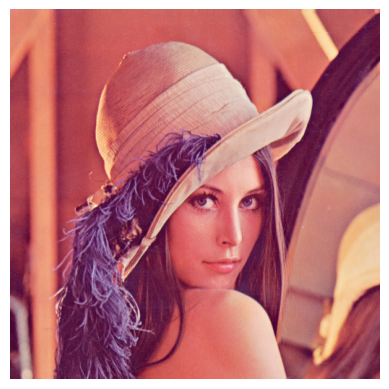

In [3]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

### Générer la version en niveaux de gris

Dans cette étape, nous convertissons l'image en niveaux de gris pour simplifier l'application des filtres de convolution. Une image en niveaux de gris ne possède qu'un seul canal (channel), ce qui signifie que notre filtre de convolution n'aura également qu'une seule dimension de profondeur (1×1×3×3 en format PyTorch).

**Note importante** : Dans les réseaux de neurones convolutifs (CNN) réels, les filtres ont généralement plusieurs canaux en entrée et en sortie. Par exemple :
- Un filtre appliqué à une image RGB aurait 3 canaux d'entrée (R, G, B)
- Les couches intermédiaires peuvent avoir des dizaines, voire des centaines de canaux
- Cela permet au réseau d'apprendre des caractéristiques plus riches et complexes

Pour ce TP, nous utilisons des niveaux de gris pour mieux visualiser et comprendre l'effet des filtres de base.

**Instructions** :
- Exploitez `cv2.cvtColor` pour produire une image monochrome (1 seul channel) à partir de l'image BGR
- Affichez-la avec une colormap `gray` et sans repères d'axes
- Cela permettra d'évaluer l'effet du filtrage basé uniquement sur les intensités


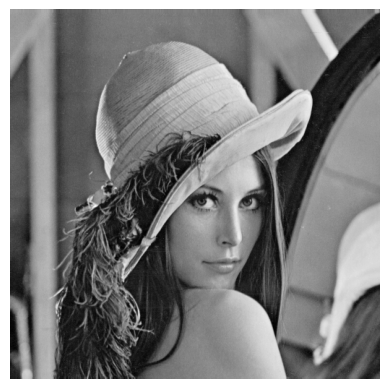

In [4]:
# Conversion de l'image en niveaux de gris
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Affichage de l'image en niveaux de gris
plt.imshow(image_gray, cmap='gray')
plt.axis('off')
plt.show()

### Convoluer l'image avec un filtre de contours

Définissez la fonction `apply_convolution` qui prend en entrée une image en niveaux de gris (tableau numpy 2D) et un noyau de convolution (tableau numpy 2D), puis retourne l'image filtrée.  

**Paramètres** :  
- `image_input` : image à filtrer, de type `numpy.ndarray`, attendue en niveaux de gris (2D)  
- `kernel` : noyau de convolution, de type `numpy.ndarray` (2D)  

- Image filtrée, de type `torch.Tensor` (avec dimensions batch et channel)

La fonction convertit les entrées en tenseurs PyTorch, ajoute les dimensions nécessaires (batch et channel), applique la convolution 2D avec padding pour conserver la taille, puis retourne le résultat sous forme de tableau numpy.  

(cf. exemple ci après)


In [ ]:
# Définir une fonction qui applique un filtre de convolution à une image
def apply_convolution(image, kernel):
    """
    Applique un filtre de convolution à une image en niveaux de gris.
    
    Parameters:
    -----------
    image_input : numpy.ndarray
        Image en niveaux de gris (2D array)
    kernel : numpy.ndarray
        Noyau de convolution (2D array)
    
    Returns:
    --------
    torch.Tensor
        Image filtrée (4D tensor with batch and channel dimensions)
    """
    # Convertir le noyau en tenseur torch et ajouter les dimensions batch/channel
    kernel_tensor = torch.from_numpy(kernel).float().unsqueeze(0).unsqueeze(0)
    
    # Convertir l'image en tenseur torch et ajouter les dimensions batch/channel
    image_tensor = torch.from_numpy(image).float().unsqueeze(0).unsqueeze(0)
    
    # Appliquer la convolution avec padding pour conserver la taille
    filtered = F.conv2d(image_tensor, kernel_tensor, padding=kernel.shape[0]//2)
    
    return filtered



### Définir et appliquer un filtre de détection de contours

Définir un noyau de convolution spécifique pour la détection de contours et l'appliquer à l'image en niveaux de gris.

**Le noyau de détection de contours (Laplacien)** :
- C'est une matrice 3×3 qui permet de détecter les variations d'intensité dans l'image
- Les valeurs négatives (-1) entourent une valeur centrale positive (4)
- Ce filtre met en évidence les zones où l'intensité change rapidement (contours, bordures)
- La somme des coefficients est égale à 0, ce qui signifie que les zones uniformes donneront une réponse nulle

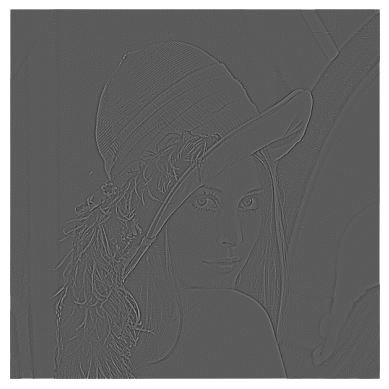

In [6]:
# Définition du noyau de contour (embossing kernel)
contour_kernel = np.array([[0, -1, 0],
                           [-1, 4, -1],
                           [0, -1, 0]])

# Appliquer la fonction avec le noyau de contour et l'image en niveaux de gris
filtered_image = apply_convolution(image_gray, contour_kernel)

numpy_image = filtered_image.squeeze().numpy()
plt.imshow(numpy_image, cmap='gray')
plt.axis('off')
plt.show()


### Inspecter la distribution des intensités filtrées

In [7]:
np.unique(filtered_image)

array([-181., -174., -172., -169., -166., -164., -160., -159., -156.,
       -155., -154., -153., -151., -150., -149., -148., -147., -146.,
       -145., -144., -143., -142., -141., -140., -139., -138., -137.,
       -136., -135., -134., -133., -132., -131., -130., -129., -128.,
       -127., -126., -125., -124., -123., -122., -121., -120., -119.,
       -118., -117., -116., -115., -114., -113., -112., -111., -110.,
       -109., -108., -107., -106., -105., -104., -103., -102., -101.,
       -100.,  -99.,  -98.,  -97.,  -96.,  -95.,  -94.,  -93.,  -92.,
        -91.,  -90.,  -89.,  -88.,  -87.,  -86.,  -85.,  -84.,  -83.,
        -82.,  -81.,  -80.,  -79.,  -78.,  -77.,  -76.,  -75.,  -74.,
        -73.,  -72.,  -71.,  -70.,  -69.,  -68.,  -67.,  -66.,  -65.,
        -64.,  -63.,  -62.,  -61.,  -60.,  -59.,  -58.,  -57.,  -56.,
        -55.,  -54.,  -53.,  -52.,  -51.,  -50.,  -49.,  -48.,  -47.,
        -46.,  -45.,  -44.,  -43.,  -42.,  -41.,  -40.,  -39.,  -38.,
        -37.,  -36.,

### Introduire une non-linéarité de type ReLU

Appliquez `torch.relu` à la carte filtrée pour annuler les réponses négatives (stocker dans `relu_filtered`), puis affichez la nouvelle image afin de visualiser l'impact de cette opération sur la mise en évidence des contours.

**Note importante sur ReLU dans les CNN** : Dans les architectures de réseaux de neurones convolutifs modernes, la fonction ReLU (Rectified Linear Unit) est systématiquement appliquée **après chaque couche de convolution**. Cette non-linéarité permet au réseau d'apprendre des représentations complexes et non-linéaires des données. Sans ReLU (ou d'autres fonctions d'activation), un empilement de couches convolutives ne serait qu'une transformation linéaire, limitant drastiquement la capacité d'apprentissage du réseau.


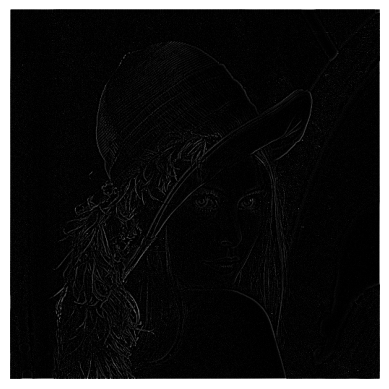

In [8]:
# Appliquer la fonction ReLU pour éliminer les valeurs négatives
relu_filtered = torch.relu(filtered_image)

# Visualiser le résultat
plt.imshow(relu_filtered.squeeze().numpy(), cmap='gray')
plt.axis('off')
plt.show()

### Re-inspecter après ReLU

Listez les valeurs uniques du tenseur transformé pour vérifier la suppression effective des intensités négatives et apprécier la compression de la plage dynamique.


In [9]:
# Voir les valeurs uniques après ReLU
np.unique(relu_filtered)

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
       143., 144., 145., 146., 147., 148., 149., 15

### Définition des filtres classiques de convolution

Définissez plusieurs filtres de convolution classiques utilisés en traitement d'image et vision par ordinateur.

**NB : vous noterez que les filtres peuvent être plus larges que 3×3**

- **Identité** : Filtre neutre qui renvoie l'image inchangée
- **Laplacien (Contours)** : Détection des contours dans toutes les directions (détection de bords)
- **Sobel Horizontal/Vertical** : Détection de contours directionnels (reconnaissance de formes, analyse de textures)
- **Accentuation (Sharpen)** : Augmente la netteté de l'image (amélioration d'image)
- **Relief (Emboss)** : Crée un effet de relief 3D (effets artistiques, extraction de textures)
- **Flou (Box Blur)** : Lissage uniforme de l'image (réduction de bruit)
- **Flou Gaussien** : Lissage pondéré privilégiant les pixels centraux (réduction de bruit, pyramides d'images, détection de blob)

In [28]:
# Filtre identité (neutre)
identity_kernel = np.array([[0, 0, 0],
                            [0, 1, 0],
                            [0, 0, 0]])

# Filtre de détection de contours 5x5 (Laplacien étendu)
laplacian_5x5 = np.array([[-1, -1, -1, -1, -1],
                            [-1, -1, -1, -1, -1],
                            [-1, -1, 24, -1, -1],
                            [-1, -1, -1, -1, -1],
                            [-1, -1, -1, -1, -1]])

# Filtre de détection de contours horizontaux (Sobel horizontal)
sobel_horizontal = np.array([[-1, -2, -1],
                              [ 0,  0,  0],
                              [ 1,  2,  1]])

# Filtre Sobel 5x5 vertical
sobel_5x5_vertical = np.array([[-1, -2, -3, -2, -1],
                                [-2, -3, -5, -3, -2],
                                [ 0,  0,  0,  0,  0],
                                [ 2,  3,  5,  3,  2],
                                [ 1,  2,  3,  2,  1]])

# Filtre de détection de contours verticaux (Sobel vertical)
sobel_vertical = np.array([[-1, 0, 1],
                            [-2, 0, 2],
                            [-1, 0, 1]])

# Filtre accentuation (Sharpen)
sharpen_kernel = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

# Filtre de relief (Emboss)
emboss_kernel = np.array([[-2, -1, 0],
                          [-1,  1, 1],
                          [ 0,  1, 2]])

# Filtre de flou (Box blur / Average filter)
blur_kernel = (1/9) * np.array([[1, 1, 1],
                                 [1, 1, 1],
                                 [1, 1, 1]])




# Liste des filtres à appliquer
filters = [
    # ('original', None),
    ('Identité', identity_kernel),
    ('Contours (Laplacien)', contour_kernel),
    ('Laplacien 5x5', laplacian_5x5),
    ('Sobel Horizontal', sobel_horizontal),
    ('Sobel Vertical', sobel_vertical),
    ('Sobel Vertical 5x5', sobel_5x5_vertical),
    ('Accentuation', sharpen_kernel),
    ('Relief (Emboss)', emboss_kernel),
    ('Flou (Box Blur)', blur_kernel),
    # ('Flou Gaussien', gaussian_blur),
]

### Application des filtres et affichage des résultats

Créer une fonction `display_filters` qui permet d'afficher de manière organisée les résultats de l'application de plusieurs filtres de convolution sur l'image en niveaux de gris.

**Paramètres de la fonction :**
- `image_gray` : image en niveaux de gris (numpy.ndarray)
- `filters` : liste de tuples (nom_filtre, kernel), avec kernel=None pour l'image originale
- `figsize` : tuple optionnel pour la taille de la figure (largeur, hauteur)

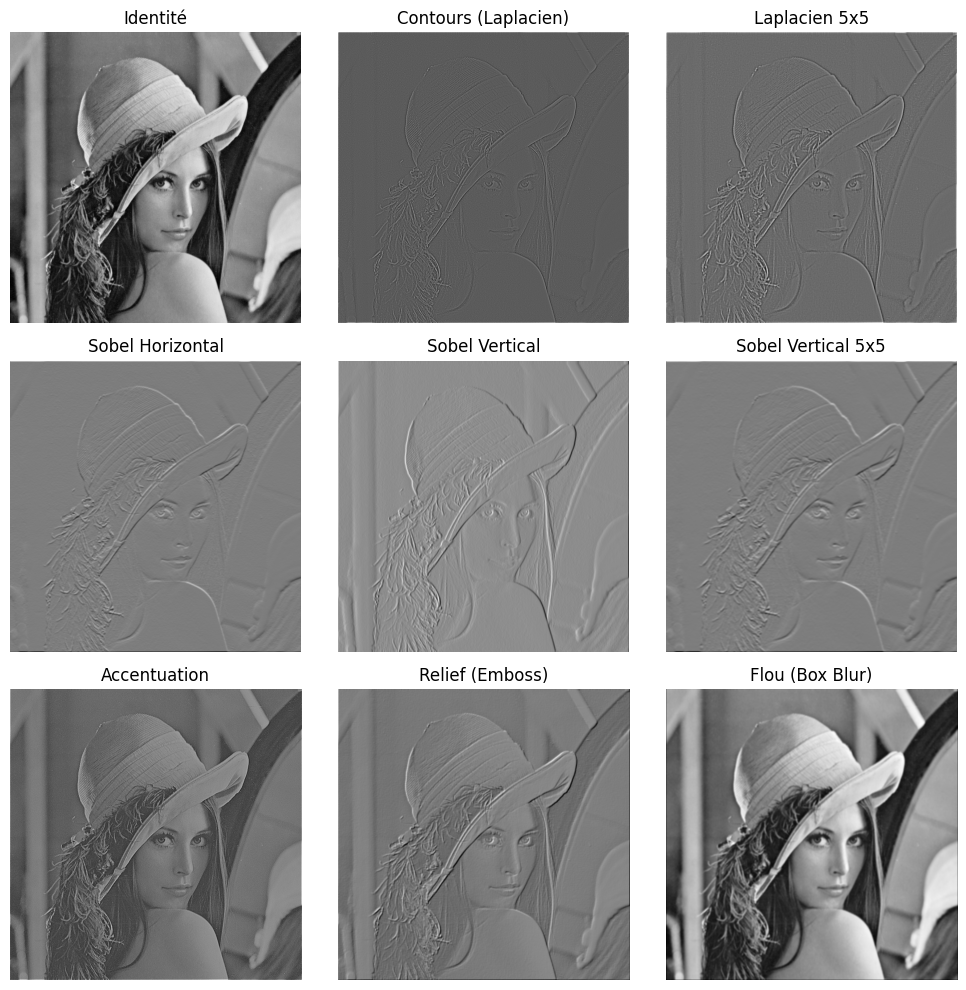

In [29]:
def display_filters(image_gray, filters, figsize=(10, 10)):
    """
    Applique et affiche une série de filtres sur une image en niveaux de gris.
    
    Parameters:
    -----------
    image_gray : numpy.ndarray
        Image en niveaux de gris (2D array)
    filters : list of tuples
        Liste de tuples (nom_filtre, kernel), avec kernel=None pour l'image originale
    figsize : tuple, optional
        Taille de la figure (largeur, hauteur)
    """
    n_filters = len(filters)
    n_cols = 3
    n_rows = (n_filters + n_cols - 1) // n_cols  # Calcul du nombre de lignes nécessaires
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # Aplatir pour faciliter l'indexation
    
    for idx, (title, kernel) in enumerate(filters):
        if kernel is None:
            # Afficher l'image originale
            axes[idx].imshow(image_gray, cmap='gray')
        else:
            # Appliquer le filtre
            filtered = apply_convolution(image_gray, kernel)
            axes[idx].imshow(filtered.squeeze().numpy(), cmap='gray')
        
        axes[idx].set_title(title, fontsize=12)
        axes[idx].axis('off')
    
    # Masquer les sous-graphiques inutilisés
    for idx in range(n_filters, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Appel de la fonction
display_filters(image_gray, filters)

### Application à diverses images

Appliquez l'ensemble des filtres définis précédemment à toutes les images disponibles dans le répertoire `img_dir`. 

Filtres appliqués sur : Lenna.png


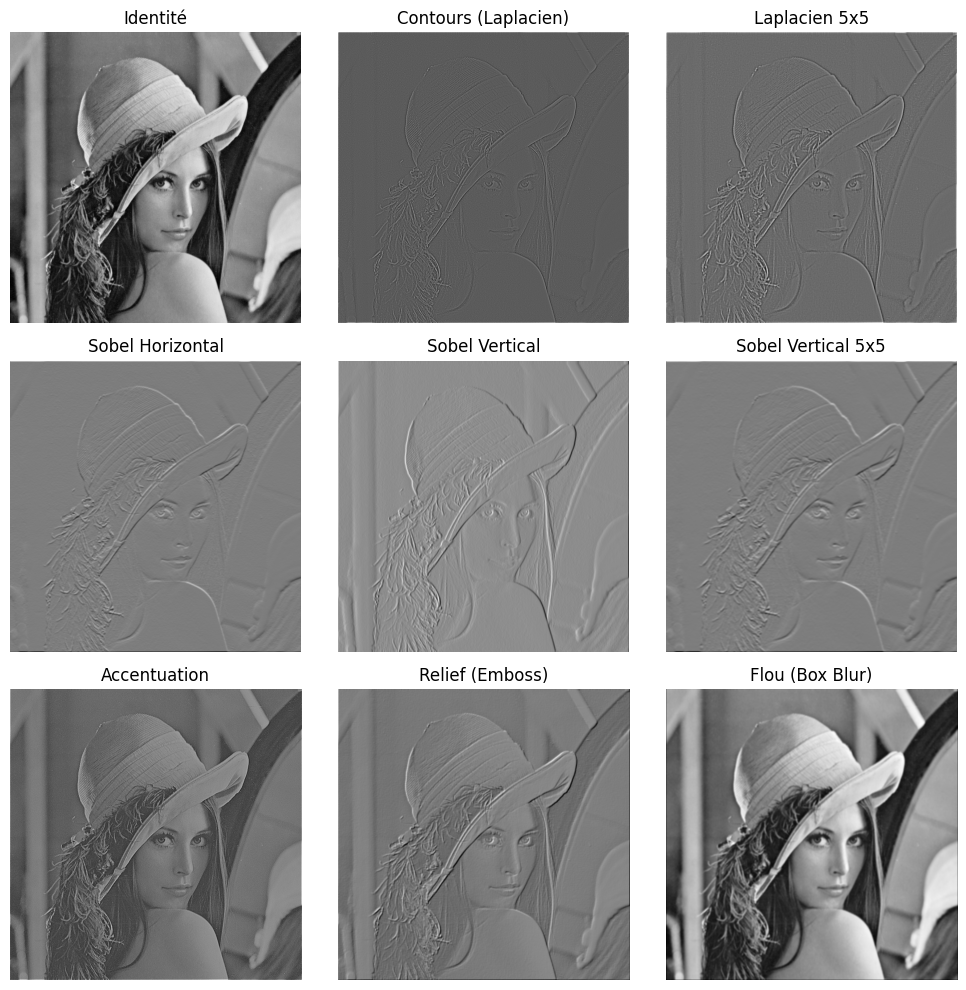

Filtres appliqués sur : wall.jpg


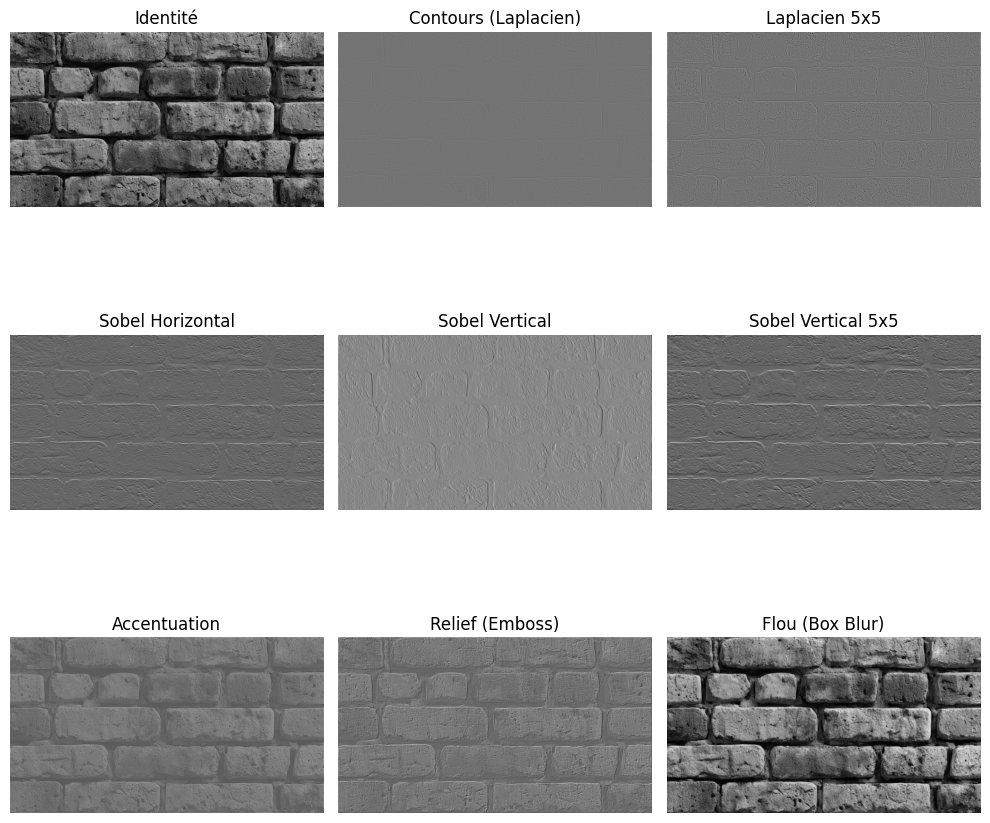

Filtres appliqués sur : isometric-pattern-lines-thumb23.jpg


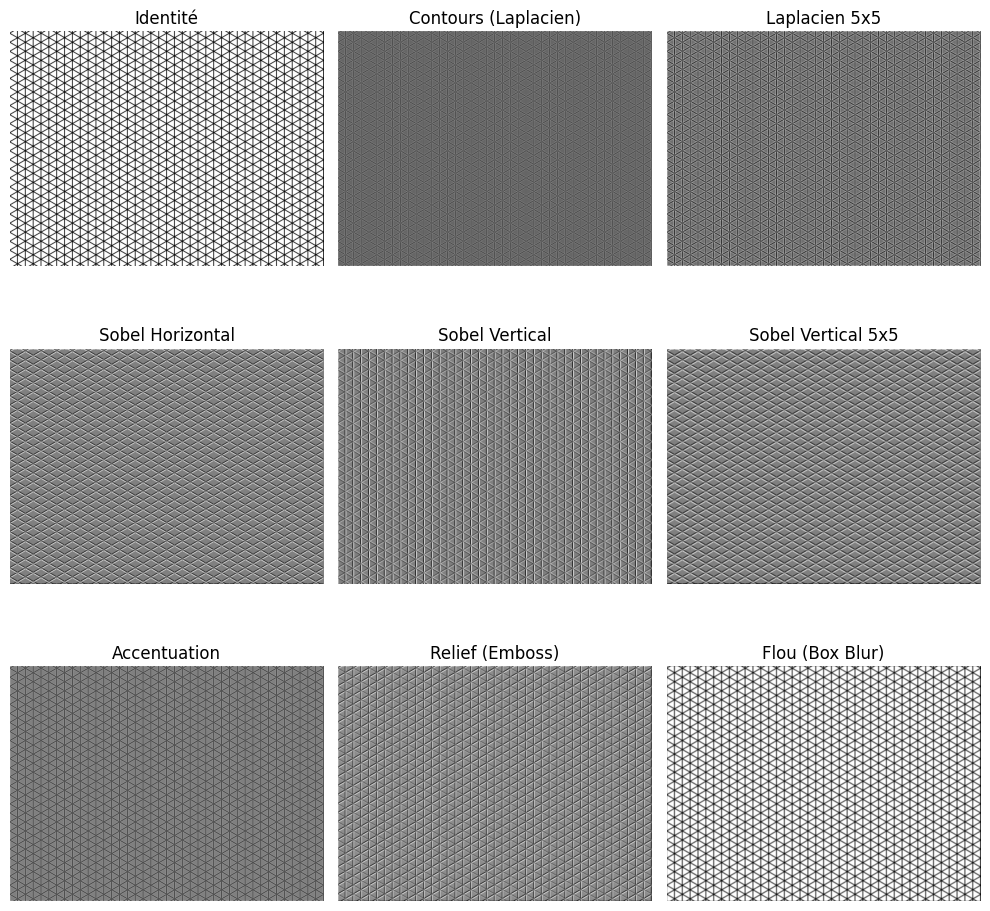

Filtres appliqués sur : geometrical-signs-circles-and-squares-high-contrast-retro-seamless-pattern-in-black-and-white.jpg


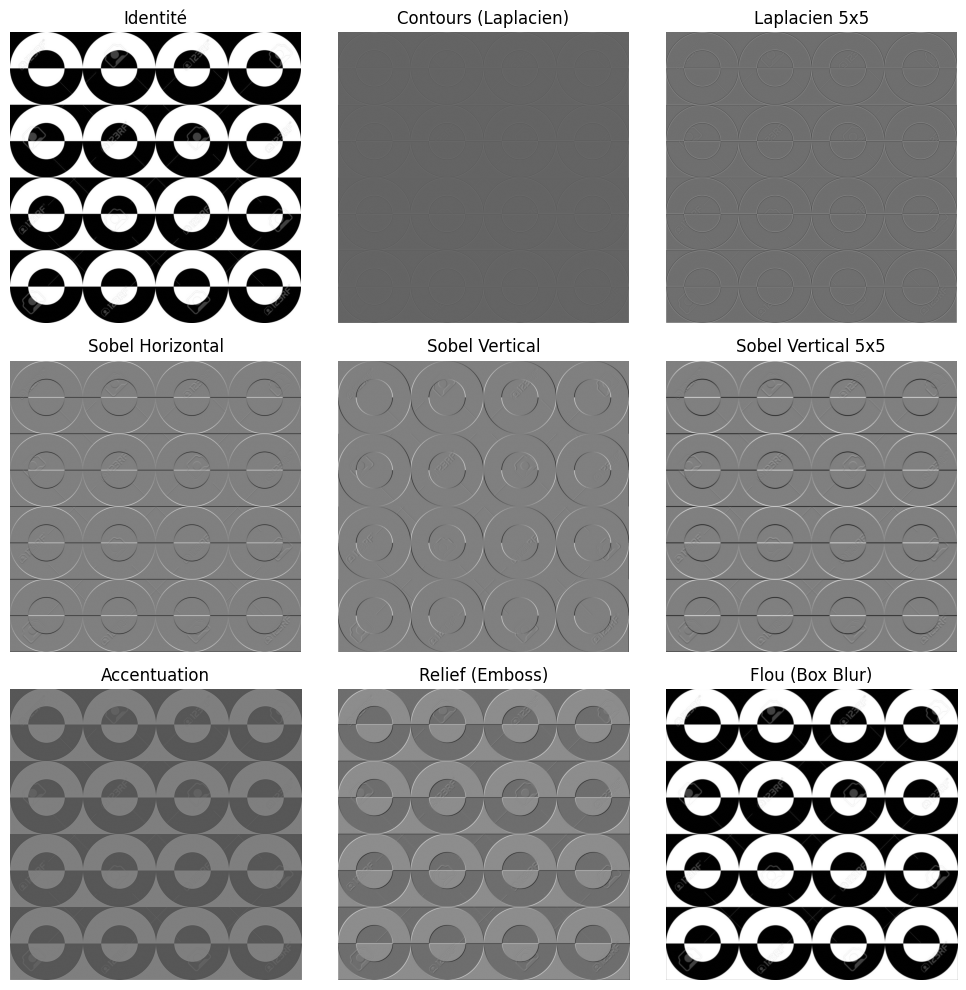

Filtres appliqués sur : pngtree-grid-black-and-white-simple-square-plaid-straight-line-square-geometric-png-image_6094597.png


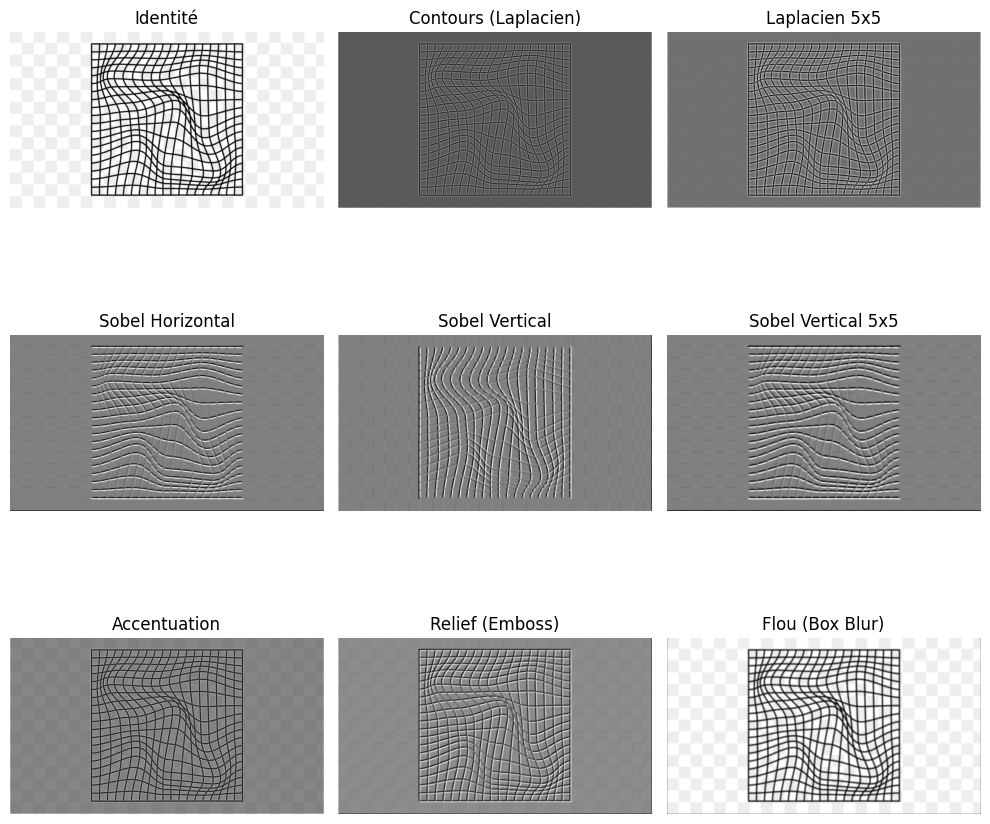

Filtres appliqués sur : camera.png


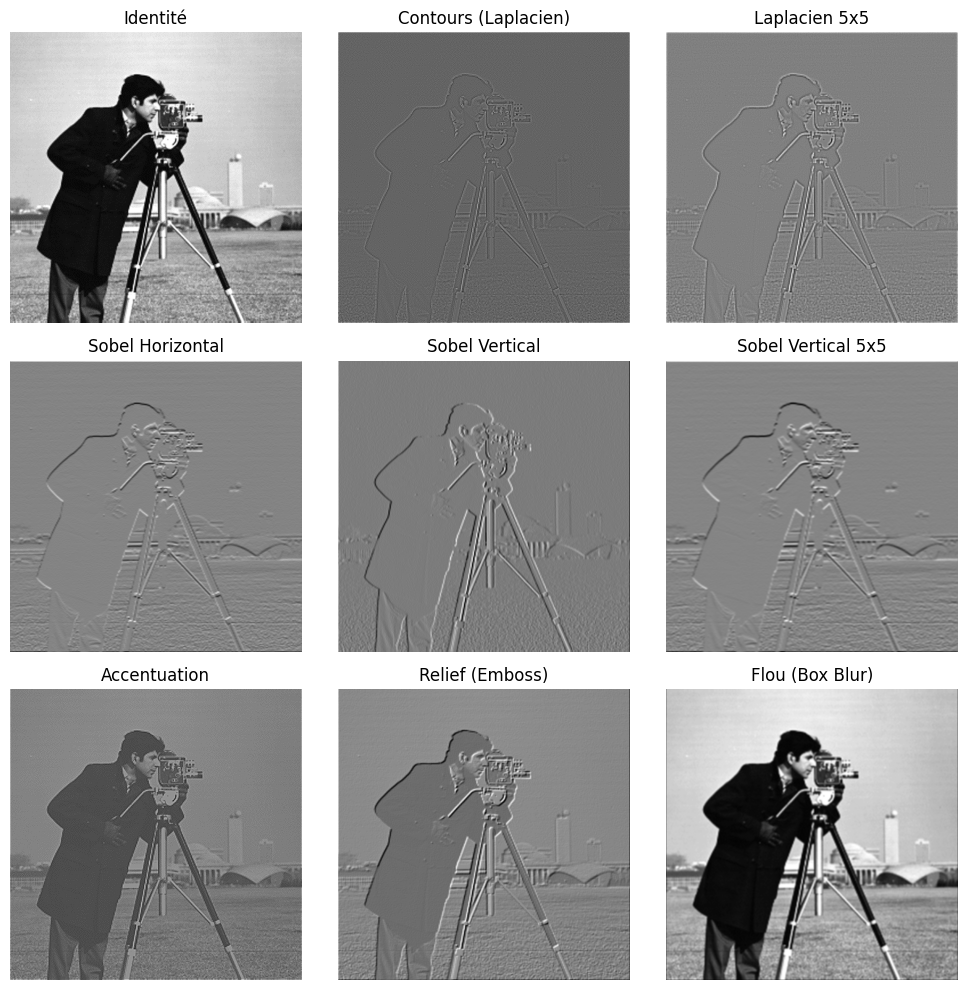

Filtres appliqués sur : mandrill.png


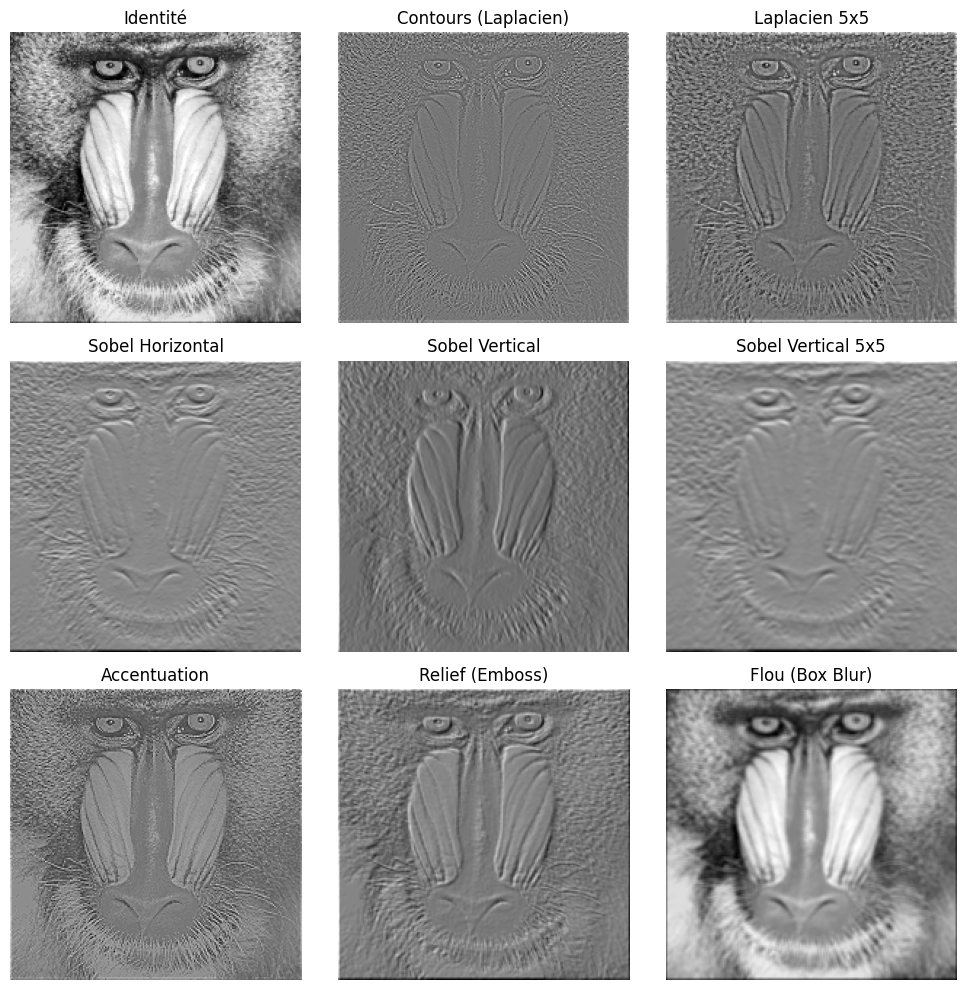

In [30]:
# Lister tous les fichiers image dans le dossier
image_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]

for fname in image_files:
    img = cv2.imread(os.path.join(img_dir, fname))
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    print(f"Filtres appliqués sur : {fname}")
    display_filters(img_gray, filters)

## Intérêt dans le cadre des CNN

Les filtres présentés ici sont des exemples classiques issus du traitement d'images traditionnel, avec des rendus compréhensibles par les humains et utiles en pré-traitement.

Dans un réseau de neurones convolutif (CNN), les filtres ne sont pas définis manuellement : ils sont initialisés aléatoirement puis appris automatiquement lors de l'entraînement, en optimisant la performance sur une tâche donnée (classification, détection, etc.).

Un CNN utilise généralement des dizaines, voire des centaines de filtres par couche, permettant d'extraire des caractéristiques complexes et adaptées aux données, bien au-delà des filtres "faits main" classiques.

C'est cette capacité d'apprentissage automatique des filtres qui fait la puissance des CNN en vision par ordinateur :

- Les premiers filtres apprennent souvent des motifs simples (bords, textures)
- Les couches profondes combinent ces motifs pour détecter des formes plus abstraites et spécifiques à la tâche
- Les filtres sont optimisés pour maximiser la performance globale du réseau, et non pour être interprétables par l'humain

Ainsi, les CNN surpassent largement les méthodes classiques en adaptant dynamiquement leurs filtres à la complexité des images réelles.